# First Run of a AutoRegressive-LSTM on the App **MASSA**
 
**Paramaters**
The objective of this first run is to do it as simple as possible, to control if the set up is correct and that the code works fine.
- the config file:  *ARLSTM_v0.yml*
- basins folder:    *../data/basins.txt* (only massa)
- dataset file:     *../../../data/Massa/massa.csv*

For now, we only use 2 dynamical forcing variables:
1. precipitation at the station Bruchji: prec_bruchji (column CV)
2. temperature at the station Binn: temp_binn (column Y)

**NOTE:** no controle of the quality of the dataset has been made for now.

### Imports

In [13]:
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
import torch

from neuralhydrology.evaluation import metrics
from neuralhydrology.nh_run import start_run, eval_run
from neuralhydrology.datasetzoo import register_dataset

### Adding our Dataset | Metrics | Models

In [14]:
from custom.dataset.swisshourly import SwissHourly
register_dataset("swisshourly", SwissHourly)  # key used in your YAML
from neuralhydrology.utils.config import Config

# Custom functions plot_training_curves
from custom.functions.Plot import plot_hydrograph, plot_training_curves, plot_validation_metrics
from custom.functions.utils_fla import parse_neuralhydrology_log


---

In [ ]:
configPath = Path("24h_v1.yml")
cfg = Config(configPath)
TRAIN = False
Evaluation_TEST = False

### Training

In [16]:
if TRAIN:
    print(" Starting the training  ")
    # by default we assume that you have at least one cuda-capable nvidia gpu or macos with metal support
    if torch.cuda.is_available() or torch.backends.mps.is_available():
        print("Using GPU")
        start_run(config_file=Path(configPath))
    # fall back to cpu-only mode
    else:
        print("Using CPU")
        start_run(config_file=Path(configPath), gpu=-1)
    print("==================================")
    print("  Training ended successfully !   ")
    print("==================================")
else: print(" Training step skipped !")

 Training step skipped !


✅ Parsed 30 training epochs and 6 validation evaluations.
Plotting the losses and metrics throughout the training process: 


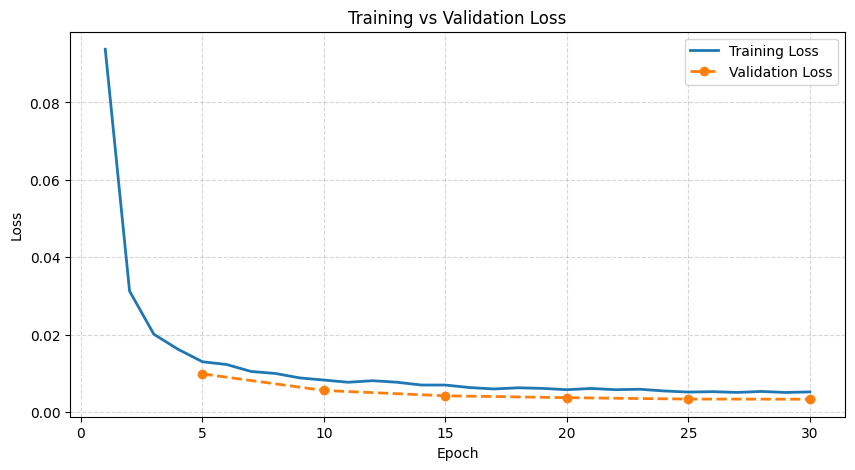

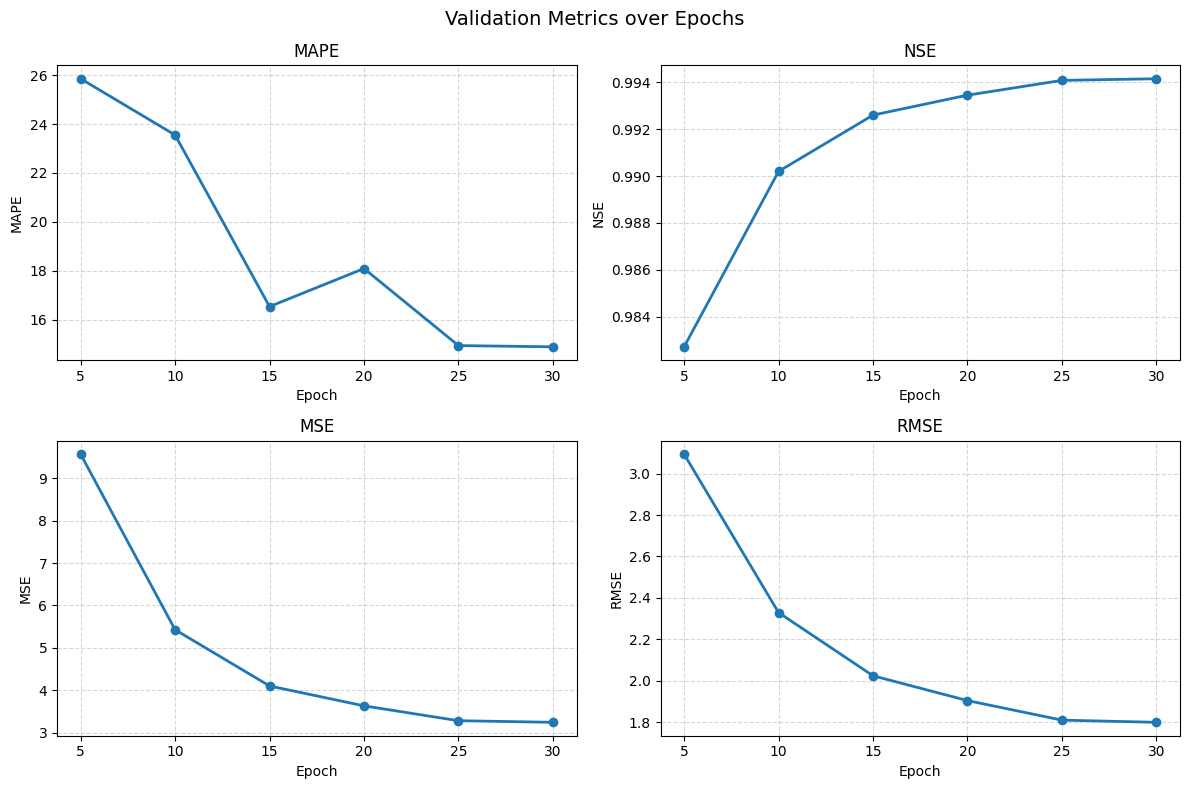

In [17]:
# Path to your output.log file
log_path = Path(f"{cfg.base_run_dir}/{cfg.run_dir}/output.log")
train_df, val_df = parse_neuralhydrology_log(log_path)

print("Plotting the losses and metrics throughout the training process: ")
plot_training_curves(train_df, val_df)
plot_validation_metrics(val_df)


---

## Evaluation on the TEST Dataset
The run directory that needs to be specified for evaluation is printed in the output log above. Since the folder name is created dynamically (including the date and time of the start of the run) you will need to change the `run_dir` argument according to your local directory name. By default, it will use the same device as during the training process.

In [18]:
run_dir = Path(f"{cfg.base_run_dir}/{cfg.run_dir}")
print(run_dir)
if Evaluation_TEST:
    print(" Starting the EVALUATION on the test period:  ")
    eval_run(run_dir=run_dir, period="test")
    print("==================================")
    print("  TEST ended successfully !   ")
    print("==================================")
else: print(" Testing process skipped !")

runs\24h_30ep_v1
 Starting the EVALUATION on the test period:  
2025-10-06 16:24:04,704: Using the model weights from runs\24h_30ep_v1\model_epoch030.pt
Metrics for 1h are calculated over last 1 elements only. Ignoring 23 predictions per sequence.
# Evaluation: 100%|██████████| 1/1 [00:48<00:00, 48.88s/it]
2025-10-06 16:24:53,594: Stored metrics at runs\24h_30ep_v1\test\model_epoch030\test_metrics.csv
2025-10-06 16:24:53,597: Stored results at runs\24h_30ep_v1\test\model_epoch030\test_results.p
  TEST ended successfully !   


### Load and inspect model predictions
Next, we load the results file and compare the model predictions with observations. The results file is always a pickled dictionary with one key per basin (even for a single basin). The next-lower dictionary level is the temporal resolution of the predictions. In this case, we trained a model only on daily data ('1D'). Within the temporal resolution, the next-lower dictionary level are `xr`(an xarray Dataset that contains observations and predictions), as well as one key for each metric that was specified in the config file.

In [19]:
testPath = Path(run_dir / "test" / f"model_epoch0{cfg.epochs}" / "test_results.p")
with open(testPath, "rb") as fp:
    results = pickle.load(fp)

# results.keys()
results['massa']['1h']

{'xr': <xarray.Dataset> Size: 2MB
 Dimensions:         (date: 10201, time_step: 24)
 Coordinates:
   * date            (date) datetime64[ns] 82kB 2024-04-01T23:00:00 ... 2025-0...
   * time_step       (time_step) int64 192B -23 -22 -21 -20 -19 ... -4 -3 -2 -1 0
 Data variables:
     streamflow_obs  (date, time_step) float32 979kB 1.154 1.146 ... 27.32 26.4
     streamflow_sim  (date, time_step) float32 979kB 1.056 1.088 ... 29.12 28.63,
 'MAPE': <xarray.DataArray ()> Size: 4B
 array(15.539222, dtype=float32),
 'NSE': 0.9937856197357178,
 'MSE': 3.6855125427246094,
 'RMSE': np.float64(1.9197688774236885)}

In [20]:
from custom.functions.Plot import plot_forecast_24h, plot_forecast_horizon_24h,plot_forecast_horizon_series

xr_ds = results['massa']["1h"]["xr"]
title24 = f"Massa – {cfg.predict_last_n} | MAPE {results['massa']['1h']['MAPE']:.3f}, NSE {results['massa']['1h']['NSE']:.3f}, RMSE {results['massa']['1h']['MSE']:.3f}"

# last forecast of the horizon vs obs
plot_forecast_24h(xr_ds, title=title24).show()
# All spaghetti forecasts
# plot_forecast_24h(xr_ds, mode="spaghetti").show()


# Example: visualize forecast issued on April 10, 2024, at midnight
plot_forecast_horizon_24h(
    xr_ds,
    issue_date="2024-04-10 00:00:00"
).show()

In [21]:

plot_forecast_horizon_series(
    xr_ds,
    issue_date="2024-06-10 00:00:00",
    n_forecasts=5
).show()

The data variables in the xarray Dataset are named according to the name of the target variables, with suffix `_obs` for the observations and suffix `_sim` for the simulations.

In [22]:
# results['massa']['1h']['xr']['streamflow_obs'][0]

Let's plot the model predictions vs. the observations

Next, we are going to compute all metrics that are implemented in the NeuralHydrology package. You will find additional hydrological signatures implemented in `neuralhydrology.evaluation.signatures`.

In [23]:
qobs=results['massa']['1h']['xr']['streamflow_obs']
qsim=results['massa']['1h']['xr']['streamflow_sim']
values = metrics.calculate_all_metrics(qobs.isel(time_step=-1), qsim.isel(time_step=-1))
for key, val in values.items():
    print(f"{key}: {val:.3f}")

NSE: 0.994
MSE: 3.686
RMSE: 1.920
KGE: 0.976
Alpha-NSE: 0.977
Beta-KGE: 0.991
Beta-NSE: -0.006
Pearson-r: 0.997
FHV: -5.136
FMS: -1.612
FLV: -1888.932
Peak-Timing: nan
Peak-MAPE: 8.225
MAPE: 15.556
